<a href="https://colab.research.google.com/github/Srikar-sri1722/JALA-ACADEMY/blob/main/Assingment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv('/content/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#1. Data Import and Cleaning

### 1.  Import a CSV file into a Pandas DataFrame. Identify and drop rows with missing values

In [8]:
df = pd.read_csv('/content/train.csv')
print("Original DataFrame shape:", df.shape)
print("Missing values in the DataFrame:\n", df.isnull().sum())
df_dropped = df.dropna()
print("DataFrame shape after dropping rows with missing values:", df_dropped.shape)
print("Missing values after dropping rows:\n", df_dropped.isnull().sum().sum())

Original DataFrame shape: (891, 12)
Missing values in the DataFrame:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
DataFrame shape after dropping rows with missing values: (183, 12)
Missing values after dropping rows:
 0


### 2. Load a dataset and replace missing numerical values with the mean of the column

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age'] = df['Age'].round()
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### 3. Replace missing categorical values with the mode of the column in a DataFrame.

In [10]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#2. Data Transformation

### Create a new column in a DataFrame that is the sum of two existing columns using NumPy vectorized operations.

In [11]:
df = pd.DataFrame({
    'A': [10, 20, 30],
    'B': [1, 2, 3]
})
df["Sum"]=np.add(df["A"],df["B"])
df

,A,B,Sum
0,10,1,11
1,20,2,22
2,30,3,33


### Apply a mathematical function (e.g., square root) to all elements of a numerical column using NumPy.

In [12]:
df['A_sqrt'] = np.sqrt(df['A'])
print(df)

    A  B  Sum    A_sqrt
0  10  1   11  3.162278
1  20  2   22  4.472136
2  30  3   33  5.477226


### Normalize a numerical column in a DataFrame using MinMaxScaler from sklearn.preprocessing and explain the transformation process.

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['A_normalized'] = scaler.fit_transform(df[['A']])
print(df)

    A  B  Sum    A_sqrt  A_normalized
0  10  1   11  3.162278           0.0
1  20  2   22  4.472136           0.5
2  30  3   33  5.477226           1.0


# 3. Merging and Joining Datasets

### Merge two DataFrames based on a common key and fill any missing values in the resulting DataFrame.

In [14]:
df1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Name': ['A', 'B', 'C']
})
df2 = pd.DataFrame({
    'ID': [2, 3, 4],
    'Salary': [20000, 30000, 40000]
})
merged_df = pd.merge(df1, df2, on='ID', how='outer')
merged_df['Salary'] = merged_df['Salary'].fillna(merged_df["Salary"].mean())
print(merged_df)

   ID Name   Salary
0   1    A  30000.0
1   2    B  20000.0
2   3    C  30000.0
3   4  NaN  40000.0


###  Perform a left join on two DataFrames with different keys and handle missing data in the result.

In [15]:
df1 = pd.DataFrame({
    'emp_id': [1, 2, 3],
    'Name': ['A', 'B', 'C']
})
df2 = pd.DataFrame({
    'id': [2, 3, 4],
    'Salary': [20000, 30000, 40000]
})
left_join_df = pd.merge(df1, df2, left_on='emp_id', right_on='id', how='left')
left_join_df['Salary'] = left_join_df['Salary'].fillna(left_join_df['Salary'].median())
print(left_join_df)

   emp_id Name   id   Salary
0       1    A  NaN  25000.0
1       2    B  2.0  20000.0
2       3    C  3.0  30000.0


###  Concatenate two DataFrames along the columns and handle any duplicate column names.

In [16]:
df1 = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6]
})
df2 = pd.DataFrame({
    'B': [7, 8, 9],
    'C': [10, 11, 12]
})
concat_df = pd.concat([df1, df2], axis=1)
concat_df = concat_df.loc[:, ~concat_df.columns.duplicated()]
print(concat_df)

   A  B   C
0  1  4  10
1  2  5  11
2  3  6  12


# 4. Grouping and Aggregation

### Group a DataFrame by a categorical column and calculate the mean and standard deviation of a numerical column for each group.

In [17]:
df = pd.DataFrame({
    'Department': ['IT', 'HR', 'IT', 'HR', 'Finance'],
    'Salary': [50000, 40000, 60000, 45000, 70000]
})
result = df.groupby('Department')['Salary'].agg(['mean', 'std'])
print(result)

               mean          std
Department                      
Finance     70000.0          NaN
HR          42500.0  3535.533906
IT          55000.0  7071.067812


###  Use groupby() to calculate the sum of a column for each group, then apply a NumPy function to the grouped results

In [18]:
group_sum = df.groupby('Department')['Salary'].sum()
result = np.sqrt(group_sum)
print(result)

Department
Finance    264.575131
HR         291.547595
IT         331.662479
Name: Salary, dtype: float64


### Create a pivot table from a DataFrame that groups data by two categorical columns and summarizes a numerical column using NumPy operations.

In [19]:
df = pd.DataFrame({
    'Department': ['IT', 'IT', 'HR', 'HR', 'Finance'],
    'Gender': ['M', 'F', 'M', 'F', 'M'],
    'Salary': [50000, 60000, 40000, 45000, 70000]
})
pivot = pd.pivot_table(df,values='Salary',index='Department',columns='Gender',aggfunc='mean')
print(pivot)

Gender            F        M
Department                  
Finance         NaN  70000.0
HR          45000.0  40000.0
IT          60000.0  50000.0


# 5. Array Operations and Manipulation

### Create a NumPy array from a DataFrame column and perform element-wise operations on the array.

In [20]:
df = pd.DataFrame({
    'A': [10, 20, 30, 40]
})
arr = df['A'].to_numpy()
arr_squared = arr ** 2
print(arr)
print(arr_squared)

[10 20 30 40]
[ 100  400  900 1600]


###  Reshape a NumPy array and assign it back to a new DataFrame column.

In [21]:
reshaped = arr.reshape(-1, 1)
df['Reshaped_A'] = reshaped.flatten()
print(df)

    A  Reshaped_A
0  10          10
1  20          20
2  30          30
3  40          40


### Use NumPy to filter a DataFrame for rows where a numerical column's values are above a certain threshold.

In [22]:
filtered_df = df[df['A'].to_numpy() > 20]
print(filtered_df)

    A  Reshaped_A
2  30          30
3  40          40


# 6. Broadcasting and Vectorized Operations

###  Broadcast a NumPy array across a DataFrame column to perform a vectorized operation.

In [23]:
df = pd.DataFrame({
    'A': [10, 20, 30, 40]
})
arr = np.array([1, 2, 3, 4])
df['Result'] = df['A'] * arr
print(df)

    A  Result
0  10      10
1  20      40
2  30      90
3  40     160


###  Create a new column in a DataFrame that results from a vectorized operation on multiple columns using NumPy.

In [24]:
df = pd.DataFrame({
    'A': [10, 20, 30],
    'B': [2, 4, 6]
})
df['Score'] = np.add(df['A'], df['B']) / 2
print(df)

    A  B  Score
0  10  2    6.0
1  20  4   12.0
2  30  6   18.0


### Demonstrate broadcasting by subtracting the mean of each row from the row's elements in a DataFrame.

In [25]:
df = pd.DataFrame({
    'A': [10, 20, 30],
    'B': [20, 30, 40],
    'C': [30, 40, 50]
})
row_mean = df.mean(axis=1)
df_centered = df.sub(row_mean, axis=0)
print(df_centered)

      A    B     C
0 -10.0  0.0  10.0
1 -10.0  0.0  10.0
2 -10.0  0.0  10.0


# 7. Linear Algebra with NumPy

### Solve a system of linear equations using NumPy, and store the solution in a DataFrame.

In [30]:
# 2x+y+z=8
# x+3y+2z=13
# 3x+2y+3z=18
A = np.array([[2, 1, 1],
              [1, 3, 2],
              [3, 2, 3]])
B = np.array([8, 13, 18])
X = np.linalg.solve(A, B)
solution_df = pd.DataFrame(X, index=["x", "y", "z"], columns=["Solution"])
print(solution_df)

   Solution
x       1.5
y       1.5
z       3.5


### Compute the dot product of two columns from a DataFrame using NumPy.

In [28]:
df = pd.DataFrame({
    "A": [1, 2, 3],
    "B": [4, 5, 6]
})
dot_product = np.dot(df["A"], df["B"])
print("Dot Product:", dot_product)

Dot Product: 32


### Perform matrix multiplication on two DataFrames treated as matrices and store the result in a new DataFrame.

In [29]:
df1 = pd.DataFrame([[1, 2],
                    [3, 4]])
df2 = pd.DataFrame([[5, 6],
                    [7, 8]])
result = np.dot(df1.values, df2.values)
result_df = pd.DataFrame(result)
print(result_df)

    0   1
0  19  22
1  43  50


# 8. Handling Missing Data

###  Interpolate missing values in a DataFrame using a linear method with NumPy and Pandas.

In [31]:
df = pd.DataFrame({
    "Values": [1, np.nan, np.nan, 4, 5]
})
df["Interpolated"] = df["Values"].interpolate(method="linear")
print(df)

   Values  Interpolated
0     1.0           1.0
1     NaN           2.0
2     NaN           3.0
3     4.0           4.0
4     5.0           5.0


### Use a mask created with NumPy to fill missing values in a DataFrame with a specific value.

In [32]:
df = pd.DataFrame({
    "A": [10, np.nan, 30, np.nan]
})
mask = np.isnan(df["A"])
df.loc[mask, "A"] = 0
print(df)

      A
0  10.0
1   0.0
2  30.0
3   0.0


### Identify and replace outliers in a DataFrame column with the median value using a NumPy mask.

In [33]:
df = pd.DataFrame({
    "Data": [10, 12, 14, 100, 15, 11]
})
median = np.median(df["Data"])
mask = df["Data"] > 50
df.loc[mask, "Data"] = median
print(df)

   Data
0    10
1    12
2    14
3    13
4    15
5    11


# 9. Advanced Data Analysis


### Use a combination of groupby() and NumPy operations to analyze trends in a multi-level categorical dataset.

In [34]:
df_multi = pd.DataFrame({
    'Year': [2021, 2021, 2021, 2022, 2022, 2022],
    'Region': ['North', 'South', 'North', 'South', 'North', 'South'],
    'Sales': [100, 150, 120, 200, 180, 210]
})
trends = df_multi.groupby(['Year', 'Region'])['Sales'].agg([np.mean, np.std]).reset_index()
display(trends)

/tmp/ipykernel_9727/3524441943.py:6: FutureWarning: The provided callable <function mean at 0x7df9c8bed4e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  trends = df_multi.groupby(['Year', 'Region'])['Sales'].agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_9727/3524441943.py:6: FutureWarning: The provided callable <function std at 0x7df9c8bed620> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  trends = df_multi.groupby(['Year', 'Region'])['Sales'].agg([np.mean, np.std]).reset_index()


,Year,Region,mean,std
0,2021,North,110.0,14.142136
1,2021,South,150.0,NaN
2,2022,North,180.0,NaN
3,2022,South,205.0,7.071068


###  Create a summary DataFrame that includes the correlation matrix of numerical columns using both Pandas and NumPy.

In [35]:
df_corr = pd.DataFrame({
    'A': [1, 2, 3, 4, 5],
    'B': [5, 4, 3, 2, 1],
    'C': [2, 3, 2, 3, 2]
})
pandas_corr = df_corr.corr()
numpy_corr_vals = np.corrcoef(df_corr.values.T)
numpy_corr_df = pd.DataFrame(numpy_corr_vals, index=df_corr.columns, columns=df_corr.columns)
print("Pandas Correlation Matrix:")
display(pandas_corr)
print("\nNumPy Correlation Matrix:")
display(numpy_corr_df)

Pandas Correlation Matrix:


,A,B,C
A,1.0,-1.0,0.0
B,-1.0,1.0,0.0
C,0.0,0.0,1.0



NumPy Correlation Matrix:


,A,B,C
A,1.0,-1.0,0.0
B,-1.0,1.0,0.0
C,0.0,0.0,1.0


### Perform a rolling mean calculation on a time series dataset and visualize the result using Matplotlib.

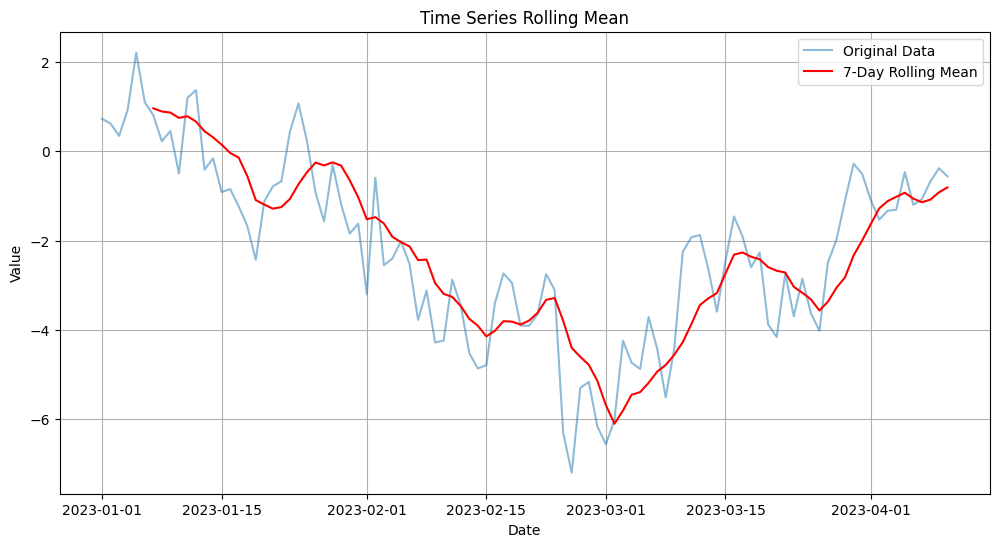

In [36]:
import matplotlib.pyplot as plt
dates = pd.date_range('2023-01-01', periods=100)
data = np.random.randn(100).cumsum()
ts_df = pd.DataFrame({'Value': data}, index=dates)
ts_df['Rolling_Mean'] = ts_df['Value'].rolling(window=7).mean()
plt.figure(figsize=(12, 6))
plt.plot(ts_df.index, ts_df['Value'], label='Original Data', alpha=0.5)
plt.plot(ts_df.index, ts_df['Rolling_Mean'], label='7-Day Rolling Mean', color='red')
plt.title('Time Series Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# 10. DataFrame and Array Manipulation

### 1. Convert a DataFrame to a NumPy array, perform an operation, and convert it back

In [38]:
df = pd.DataFrame({
    "A": [1, 2, 3],
    "B": [4, 5, 6]
})
arr = df.values
arr_result = arr * 2
df_result = pd.DataFrame(arr_result, columns=df.columns)
print(df_result)

   A   B
0  2   8
1  4  10
2  6  12


### 2. Generate a random DataFrame and filter based on multiple criteria

In [39]:
random_data = np.random.randint(0, 100, size=(10, 3))
df_random = pd.DataFrame(random_data, columns=['Score1', 'Score2', 'Score3'])
filtered_random = df_random[(df_random['Score1'] > 50) & (df_random['Score2'] < 80)]
print("Filtered Random DataFrame:")
display(filtered_random)

Filtered Random DataFrame:


,Score1,Score2,Score3
6,52,69,45
7,53,9,73
8,65,70,89


### 3. Apply a custom NumPy function to elements of two arrays to form a DataFrame

In [40]:
arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])
def custom_func(x, y):
    return x**2 + y**2
result = custom_func(arr1, arr2)
df_result = pd.DataFrame(result, columns=["Result"])
print(df_result)

   Result
0      17
1      29
2      45


# 11. Data Reshaping and Analysis

###  Use NumPy's reshape to change the shape of an array extracted from a DataFrame and analyze the reshaped data

In [43]:
df = pd.DataFrame({
    "A": [1, 2, 3, 4],
    "B": [5, 6, 7, 8]
})
arr = df.values
reshaped = arr.reshape(2, 4)
row_sum = np.sum(reshaped, axis=1)
print("Reshaped Array:\n", reshaped)
print("Row-wise Sum:", row_sum)

Reshaped Array:
 [[1 5 2 6]
 [3 7 4 8]]
Row-wise Sum: [14 22]


### Stack two DataFrames vertically and use NumPy to analyze the combined dataset.

In [42]:
df1 = pd.DataFrame({"A": [1, 2], "B": [3, 4]})
df2 = pd.DataFrame({"A": [5, 6], "B": [7, 8]})
combined_df = pd.concat([df1, df2], axis=0)
mean_values = np.mean(combined_df.values, axis=0)
print("Combined DataFrame:\n", combined_df)
print("Column-wise Mean:", mean_values)

Combined DataFrame:
    A  B
0  1  3
1  2  4
0  5  7
1  6  8
Column-wise Mean: [3.5 5.5]


### Create a 3D array using NumPy and convert it into a MultiIndex DataFrame, then perform a group operation.

In [41]:
arr_3d = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
reshaped = arr_3d.reshape(4, 2)
index = pd.MultiIndex.from_product(
    [["Layer1", "Layer2"], ["Row1", "Row2"]],
    names=["Layer", "Row"]
)
df_multi = pd.DataFrame(reshaped, index=index, columns=["Col1", "Col2"])
grouped = df_multi.groupby(level="Layer").sum()
print("MultiIndex DataFrame:\n", df_multi)
print("\nGrouped Result:\n", grouped)

MultiIndex DataFrame:
              Col1  Col2
Layer  Row             
Layer1 Row1     1     2
       Row2     3     4
Layer2 Row1     5     6
       Row2     7     8

Grouped Result:
         Col1  Col2
Layer             
Layer1     4     6
Layer2    12    14


# 12. Time Series Analysis

###  Convert a column in a DataFrame to a time series using Pandas and perform a NumPy-based operation on the time series data.

In [44]:
df = pd.DataFrame({
    "Date": ["2024-01-01", "2024-01-02", "2024-01-03"],
    "Value": [10, 20, 30]
})
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df["Squared"] = np.square(df["Value"])
print(df)

            Value  Squared
Date                      
2024-01-01     10      100
2024-01-02     20      400
2024-01-03     30      900


###  Calculate the moving average of a time series in a DataFrame using a combination of Pandas and NumPy functions.

In [45]:
data = pd.Series([10, 20, 30, 40, 50])
moving_avg = data.rolling(window=3).mean()
print("Original Data:\n", data)
print("\nMoving Average:\n", moving_avg)

Original Data:
 0    10
1    20
2    30
3    40
4    50
dtype: int64

Moving Average:
 0     NaN
1     NaN
2    20.0
3    30.0
4    40.0
dtype: float64


###  Use pd.to_datetime to convert a string column to datetime format and use NumPy to compute the time difference between rows.

In [46]:
df = pd.DataFrame({
    "Date": ["2024-01-01", "2024-01-03", "2024-01-06"]
})
df["Date"] = pd.to_datetime(df["Date"])
time_diff = np.diff(df["Date"]).astype('timedelta64[D]')
print("Time Differences (days):", time_diff)

Time Differences (days): [2 3]
